# Regression Problem to Identify the new customers ...to offer insuarnce policy based on demographic information

## import libraries 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [52]:
df = pd.read_excel('D:/Desktop/OneDrive - shivameducation.net/Documents/AJIT_YADAV/CodeBasicsBootCamp/CodeBasicsProjects/ML-Projects/HealthCarePremium-Regression/young_customers.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712
4,22,Female,Southwest,Unmarried,0,Underweight,Regular,Freelancer,25L - 40L,30,High blood pressure,Gold,15473


In [53]:
df.shape

(17563, 13)

## EXPLORATRY DATA ANALYSIS AND CLEANING PART 

###  keep all the columns name in lower case and remove blank spaces with _

In [54]:
df.columns = df.columns.str.replace(" ","_").str.lower()
df.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857


###  handle missing values

In [55]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

since in comparison to whole data .. missing values are very less in quantity ..so it can be ignored

In [56]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [57]:
# drop duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [58]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,17557.000000,17557.000000,17557.000000,17557.000000
mean,20.988609,0.715840,22.653585,8161.883237
std,1.998258,0.938388,23.777397,2764.254265
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6035.000000
50%,21.000000,0.000000,16.000000,7951.000000
75%,23.000000,1.000000,31.000000,9575.000000
max,24.000000,3.000000,790.000000,18186.000000


there are some discrepancy in dependants and income columns ... it cant be -3 for dependants and 930 lakhs for income

In [59]:
# assuming negative number of dependents is an error, we will make it positive
df['number_of_dependants'] = df['number_of_dependants'].abs()
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,17557.000000,17557.000000,17557.000000,17557.000000
mean,20.988609,0.720283,22.653585,8161.883237
std,1.998258,0.934982,23.777397,2764.254265
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6035.000000
50%,21.000000,0.000000,16.000000,7951.000000
75%,23.000000,1.000000,31.000000,9575.000000
max,24.000000,3.000000,790.000000,18186.000000


## treat numeric columns 

In [60]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns 

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

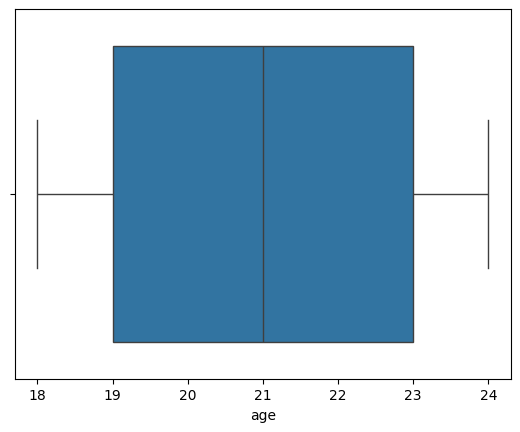

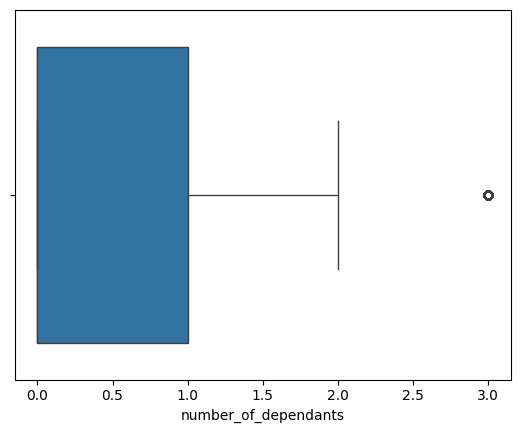

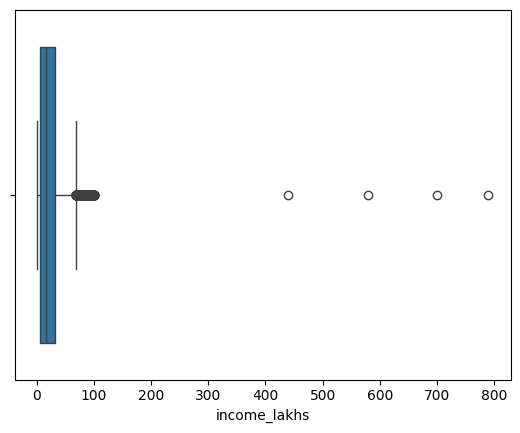

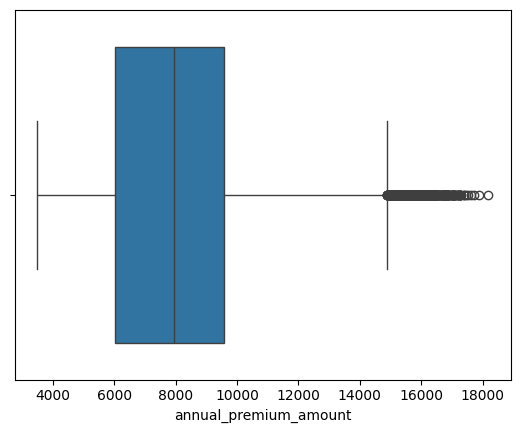

In [61]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.show()

### outliers treatment: age column

In [62]:
df = df[df['age'] <= 100]
df.describe()
df.shape

(17557, 13)

### outliers treatment: income column


<Axes: xlabel='income_lakhs', ylabel='Count'>

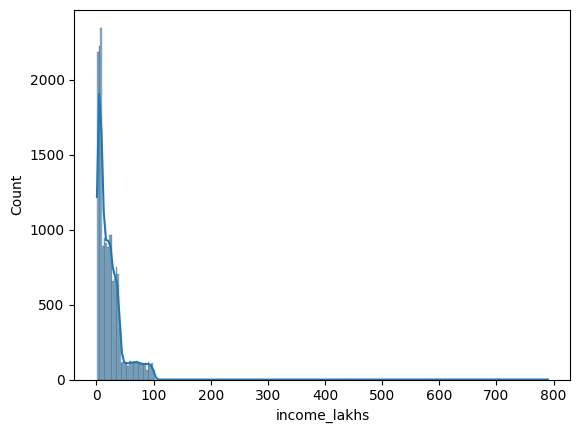

In [63]:
sns.histplot(df['income_lakhs'], kde=True)

In [64]:
# use IQR to remove outliers from the income_lakhs column
Q1 = df['income_lakhs'].quantile(0.25)
Q3 = df['income_lakhs'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound, upper_bound

(np.float64(-31.5), np.float64(68.5))

since minimum income is already given as 1 lakh so -29 don't create any trouble and it can be ignored
max age is 67 and it's very general in india ...so we can raise income bracket bit higher side

In [65]:
quantile_thresold = df.income_lakhs.quantile(0.999)
quantile_thresold

np.float64(100.0)

In [66]:
# filter the dataframe to include only rows where income_lakhs is greater than the quantile threshold
df = df[df['income_lakhs'] <= quantile_thresold]

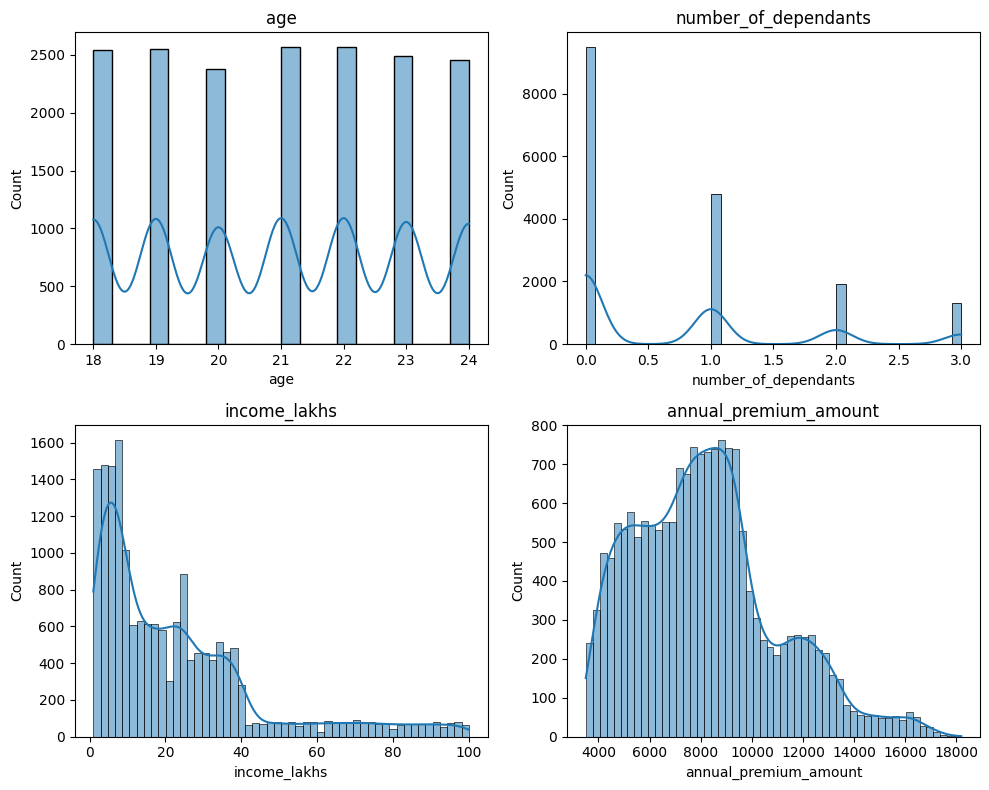

In [67]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))  # Adjust the size as necessary

for i, column in enumerate(numeric_columns):
    ax = axs[i//2, i%2]  # Determines the position of the subplot in the grid
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

## categorical column 


In [68]:
categorical_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']
for col in categorical_cols:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Not Smoking' 'Does Not Smoke'
 'Smoking=0']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


In [69]:
df['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
}, inplace=True)

C:\Users\anite\AppData\Local\Temp\ipykernel_12828\3324546496.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['smoking_status'].replace({


In [70]:
pct_count = df['gender'].value_counts(normalize=True)*100
pct_count

gender
Male      54.976357
Female    45.023643
Name: proportion, dtype: float64

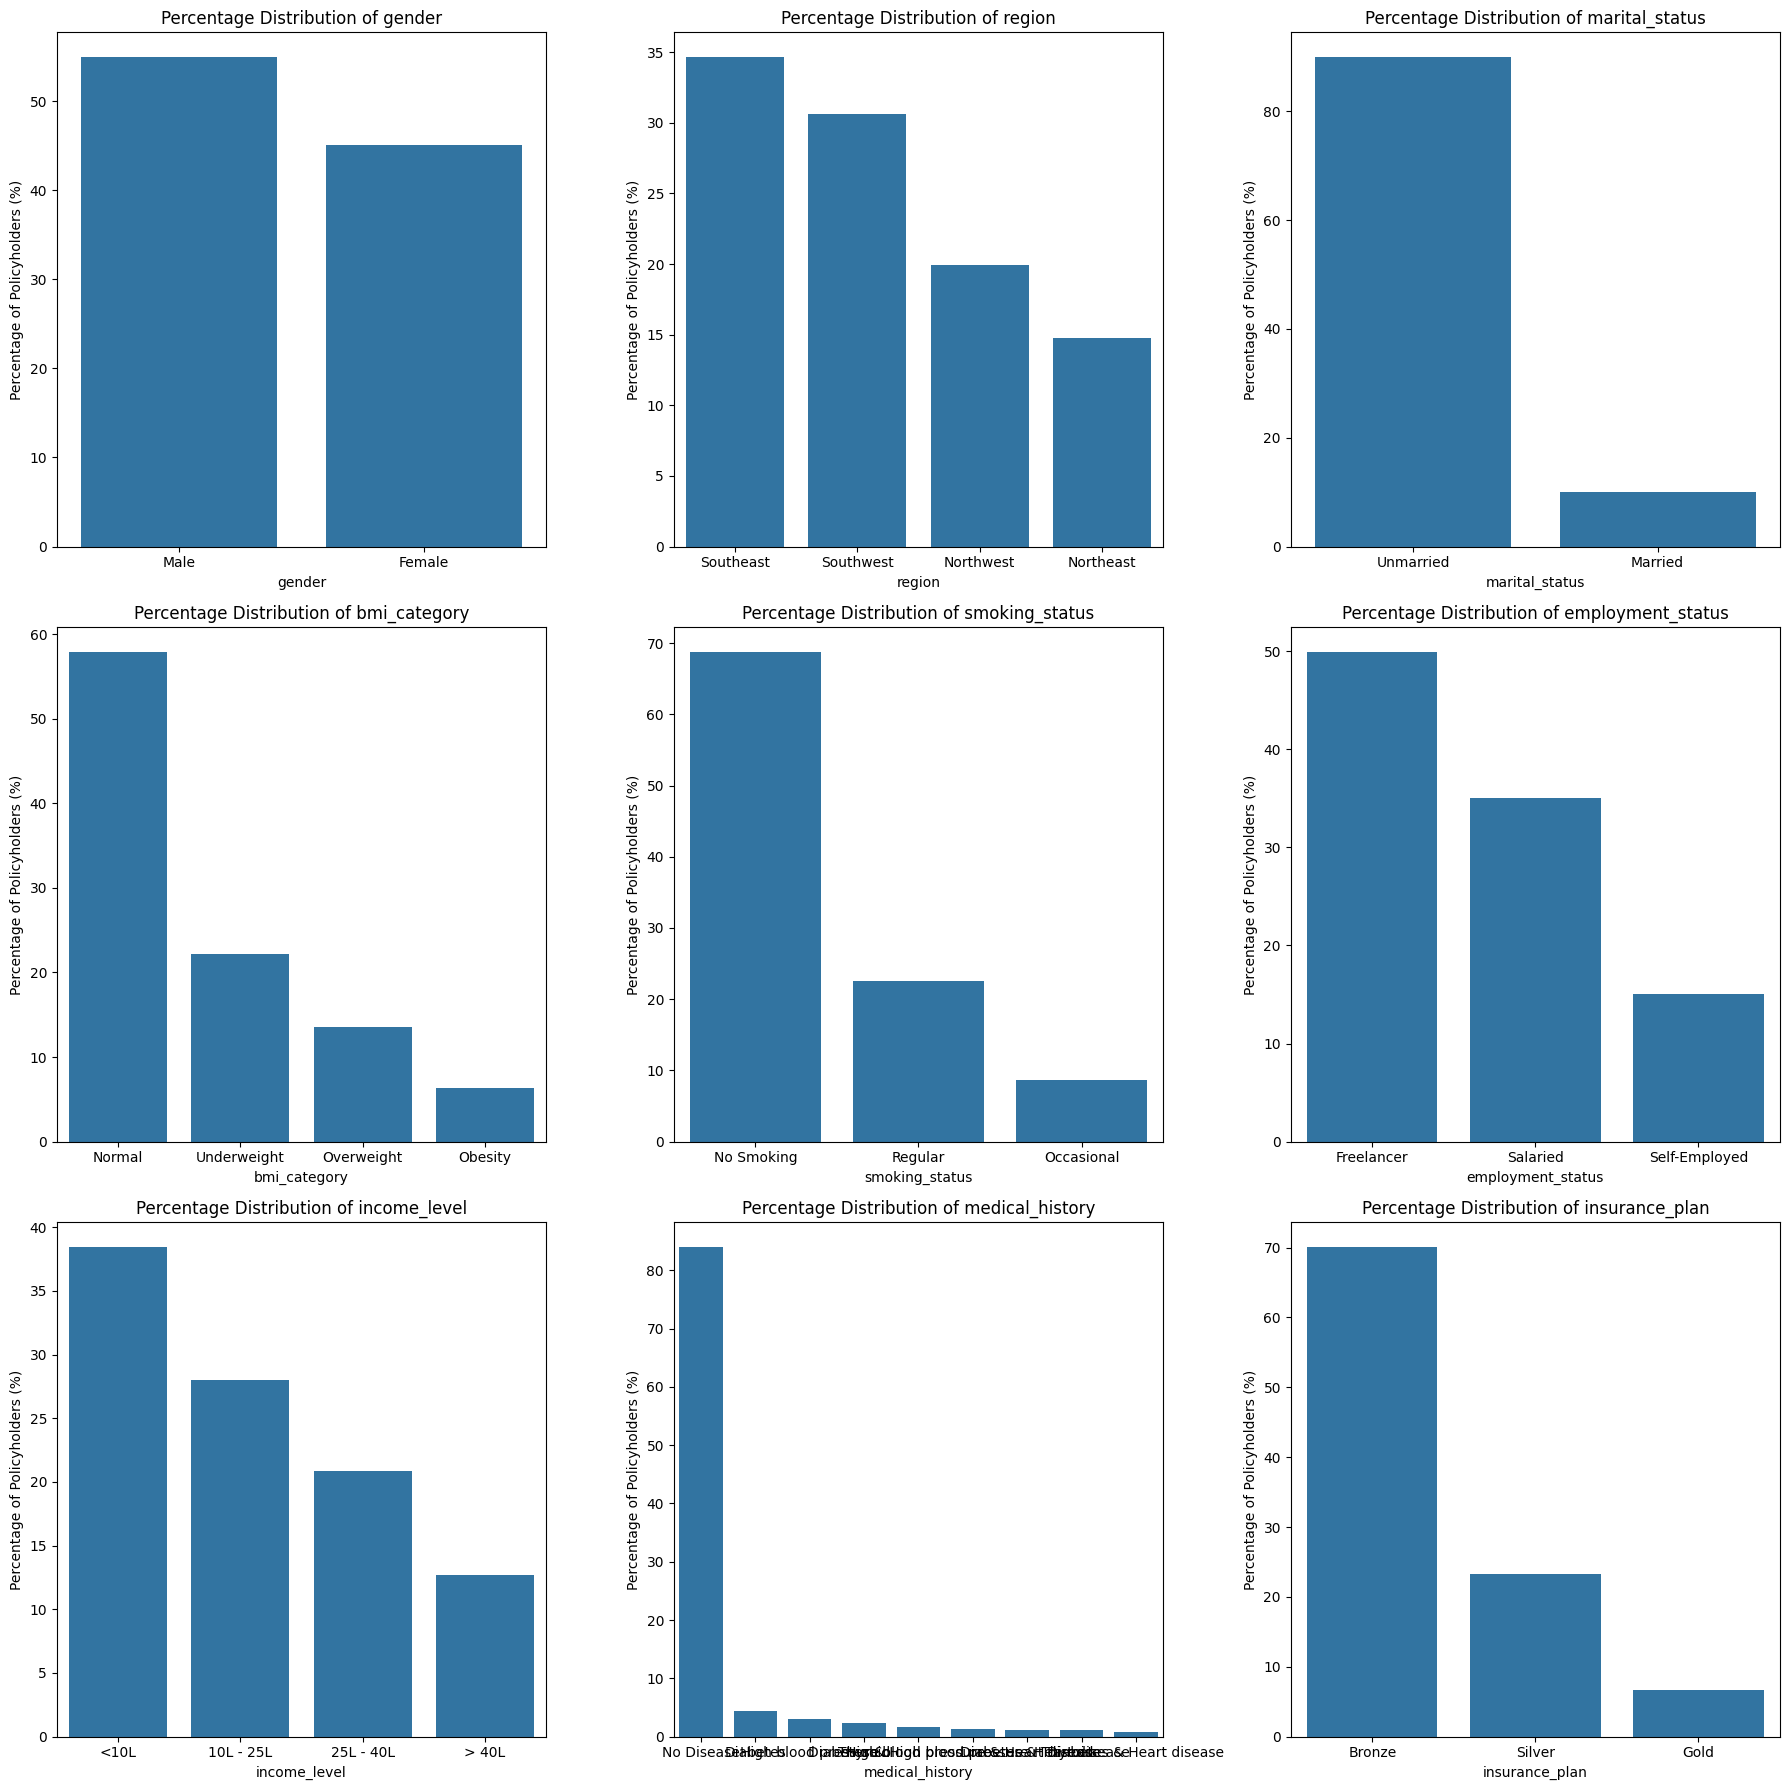

In [71]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

## FEATURE ENGINEERING 

### convert medical history values into numeric ordinal form

In [72]:
# Define the risk scores for each condition
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df[['disease1', 'disease2']] = df['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df['disease1'].fillna('none', inplace=True)
df['disease2'].fillna('none', inplace=True)
df['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df['total_risk_score'] += df[disease].map(risk_scores)

# Normalize the risk score to a range of 0 to 1
max_score = df['total_risk_score'].max()
min_score = df['total_risk_score'].min()
df['normalized_risk_score'] = (df['total_risk_score'] - min_score) / (max_score - min_score)
df.head(2)

C:\Users\anite\AppData\Local\Temp\ipykernel_12828\1247743976.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['disease1'].fillna('none', inplace=True)
C:\Users\anite\AppData\Local\Temp\ipykernel_12828\1247743976.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,none,0,0.000000


### encode text columns like .. insurance plan, income level, 

In [73]:
df['insurance_plan'] = df['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [74]:
df['income_level'] = df['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [75]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,no disease,none,0,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,no disease,none,0,...,1,0,1,0,0,0,0,1,1,0


### feature selection

In [76]:
premium1 = df.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
premium1.head(3)  

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0


### Calculate VIF for Multicolinearity

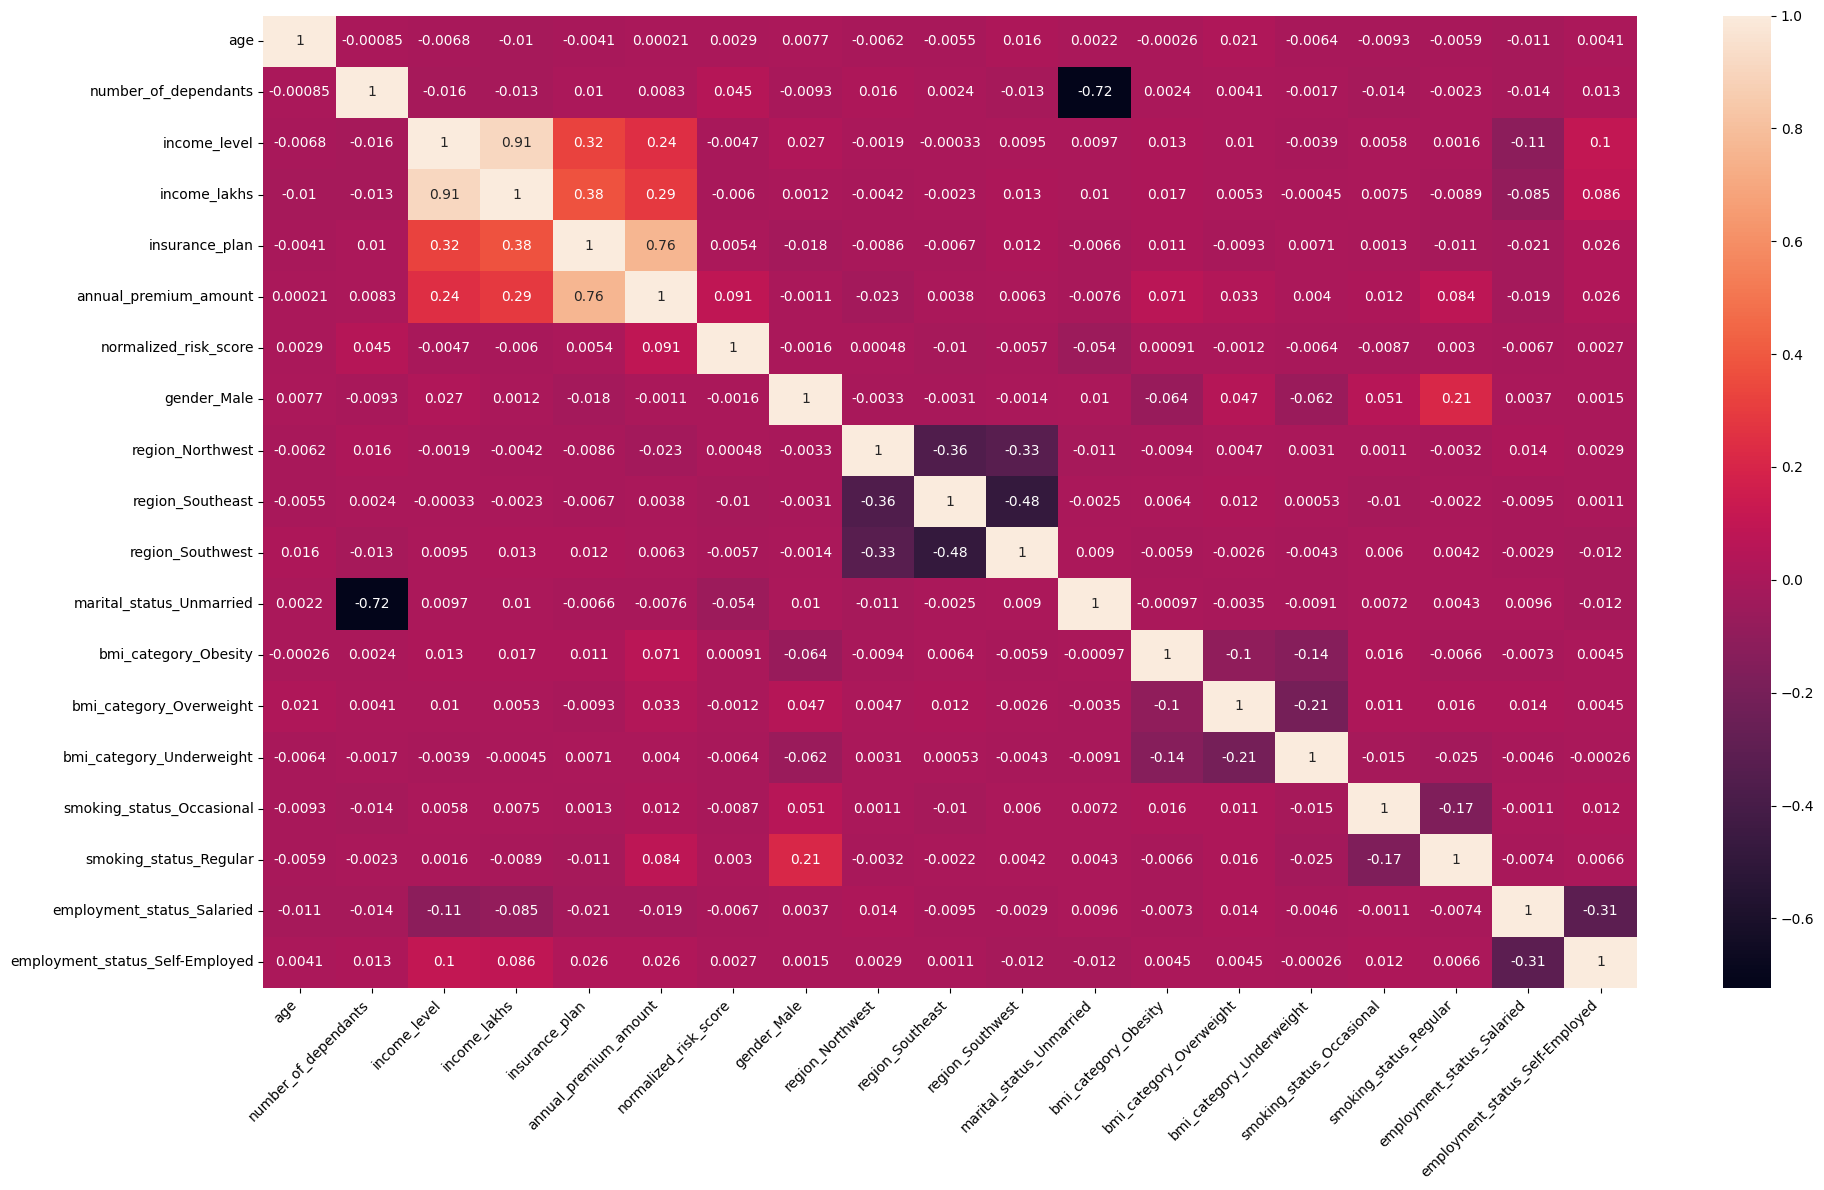

In [77]:
# correlation matrix
cm = premium1.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [78]:
X = premium1.drop('annual_premium_amount', axis='columns')
y = premium1['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000,17553.000000
mean,0.498101,0.240149,0.359236,0.217331,0.182533,0.091946,0.549764,0.199339,0.346721,0.306272,0.900131,0.063750,0.135077,0.222013,0.087108,0.225033,0.350310,0.150288
std,0.333076,0.311675,0.348758,0.220879,0.301750,0.229972,0.497532,0.399515,0.475940,0.460957,0.299834,0.244314,0.341815,0.415612,0.282001,0.417616,0.477081,0.357363
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.166667,0.000000,0.000000,0.050505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.000000,0.333333,0.151515,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.833333,0.333333,0.666667,0.303030,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [79]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [80]:
calculate_vif(X)

,Column,VIF
0,age,3.068702
1,number_of_dependants,1.855481
2,income_level,11.971912
3,income_lakhs,11.925032
4,insurance_plan,1.601270
5,normalized_risk_score,1.154314
6,gender_Male,2.312464
7,region_Northwest,2.129462
8,region_Southeast,2.956168
9,region_Southwest,2.732891


In [81]:
# drop the column with VIF greater than 10...do it one column at a time...since income level and income lakhs are highly correlated

calculate_vif(X.drop('income_level', axis="columns"))
X_reduced = X.drop('income_level', axis="columns")


## MODEL TRAINING 

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (12287, 17)
x test:  (5266, 17)
y train:  (12287,)
y test:  (5266,)


## LINEAR REGRESSION MODEL

In [83]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.6061342031678356, 0.606223344609774)

In [84]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  3009729.9929048936 RMSE:  1734.8573407934423


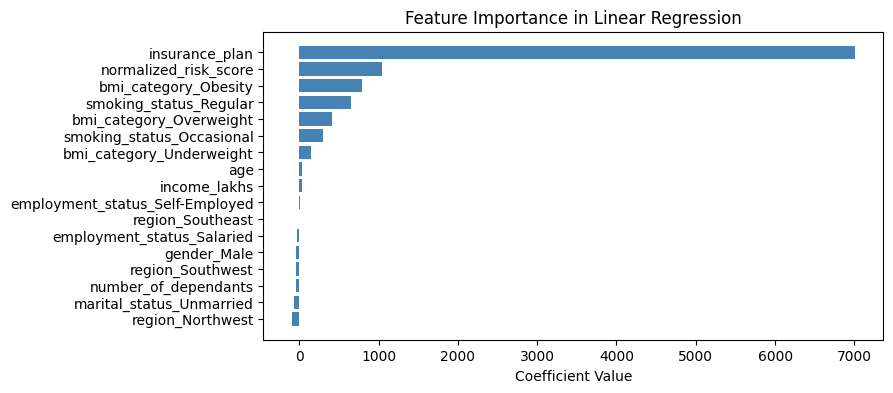

In [85]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

## Ridge Regression Model

In [86]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.606133624845288, 0.6062329764369687)

In [87]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  3009656.374525547 RMSE:  1734.8361232478262


## XG Boost

In [88]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.6056094169616699

In [89]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  3014422.75 RMSE:  1736.2093047786607


In [90]:
# RandomizedSearchCV is a powerful tool for hyperparameter tuning that allows you to search through a specified parameter grid randomly. This can be more efficient than GridSearchCV, especially when you have a large number of hyperparameters to tune. Below is an example of how to use RandomizedSearchCV with the XGBRegressor model.
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.6035029292106628)

In [91]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}

In [92]:
best_model = random_search.best_estimator_

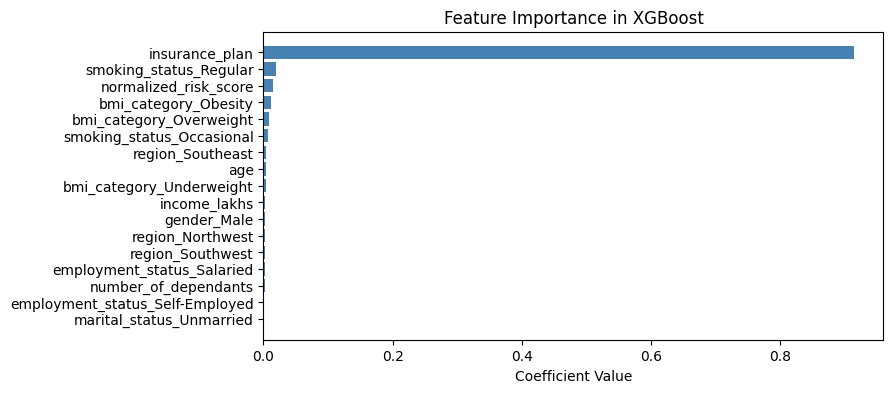

In [93]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

## ERROR ANALYSIS

In [94]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
5184,9525,6942.908203,-2582.091797,-27.108575
4370,11900,10630.409180,-1269.590820,-10.668830
10550,5606,6769.705078,1163.705078,20.758207
15707,8438,6651.881348,-1786.118652,-21.167559
4692,7626,6788.442383,-837.557617,-10.982922


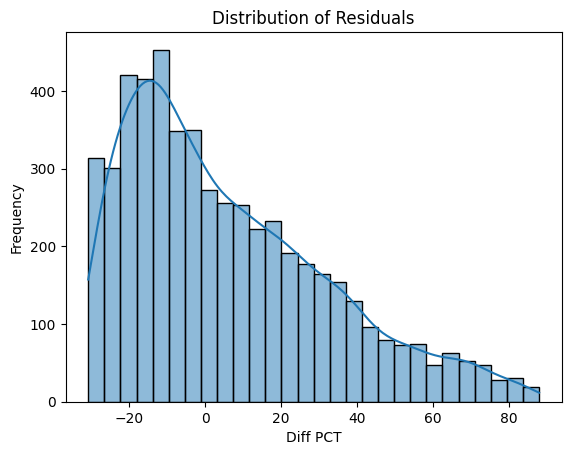

In [95]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

in the above plot .. we can see that few customers are paying very high amount as premium ... where diff PCT is more than 20-30


In [96]:
# filter the results_df to include only rows where the absolute value of diff_pct is greater than 10%
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
5184,9525,6942.908203,-2582.091797,-27.108575
4370,11900,10630.409180,-1269.590820,-10.668830
10550,5606,6769.705078,1163.705078,20.758207
15707,8438,6651.881348,-1786.118652,-21.167559
4692,7626,6788.442383,-837.557617,-10.982922


In [97]:
extreme_results_df.shape

(3840, 4)

In [98]:
results_df.shape

(5266, 4)

In [ ]:
# since this age group less than 25 so 72% error is expected
extreme_errors_pct = extreme_results_df.shape[0]*100/results_df.shape[0]
extreme_errors_pct

72.92062286365363

so 30% data having very high premium that is not good for customers 

In [100]:
# so track those customer who are being hihgly charged ...from main dataset
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
5184,0.666667,0.333333,0.333333,0.0,0.0,0,0,1,0,1,0,1,0,0,0,0,0
4370,0.666667,0.000000,0.696970,0.5,1.0,1,0,1,0,1,0,0,0,0,0,1,0


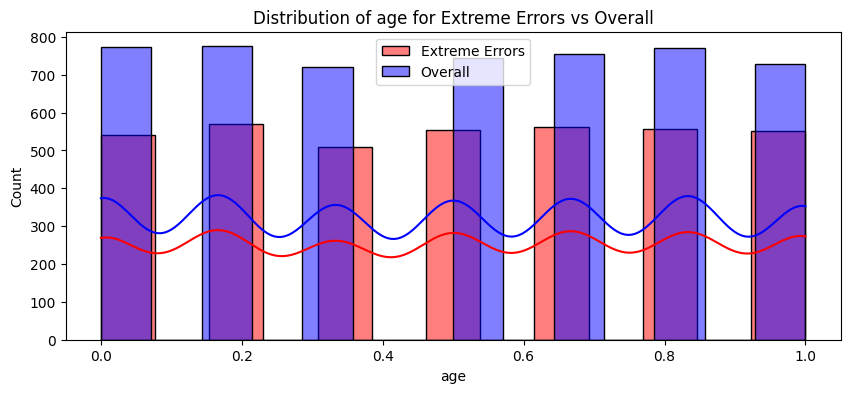

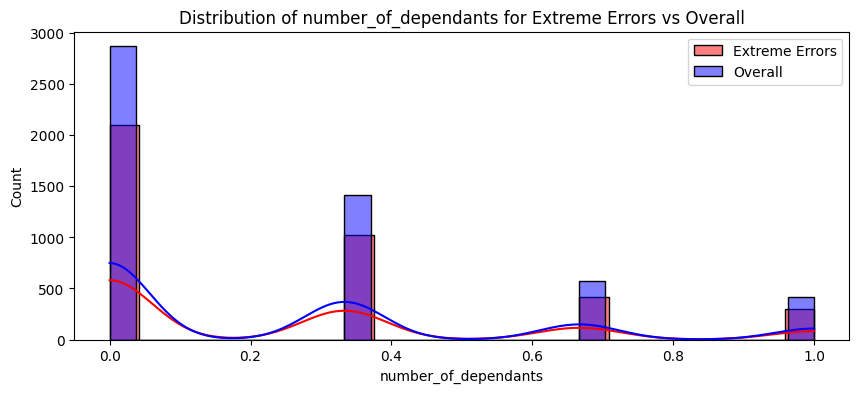

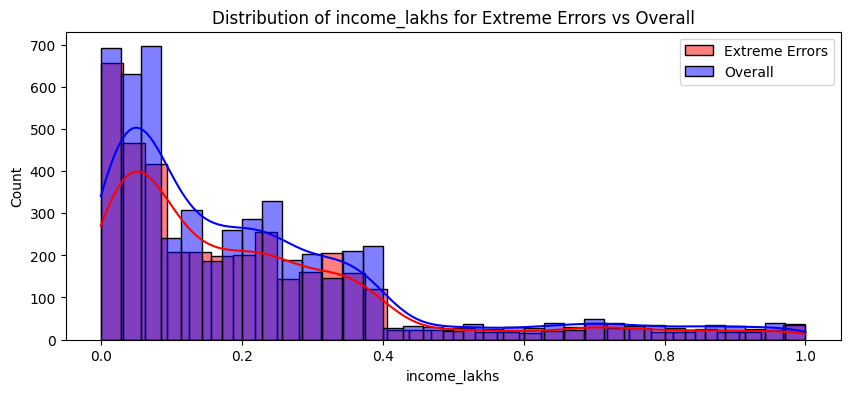

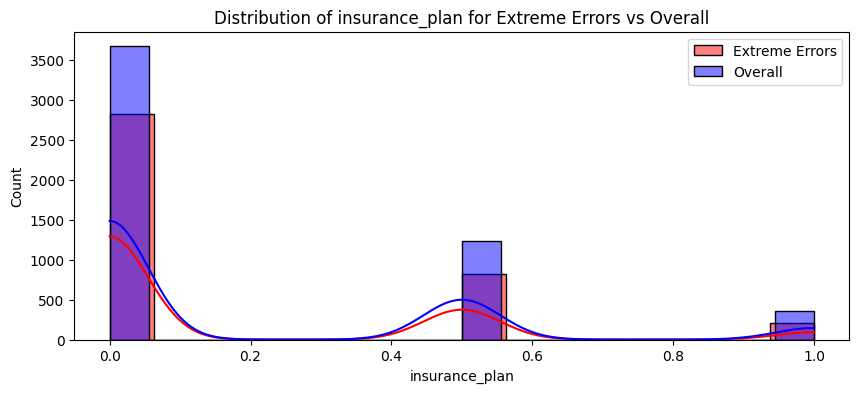

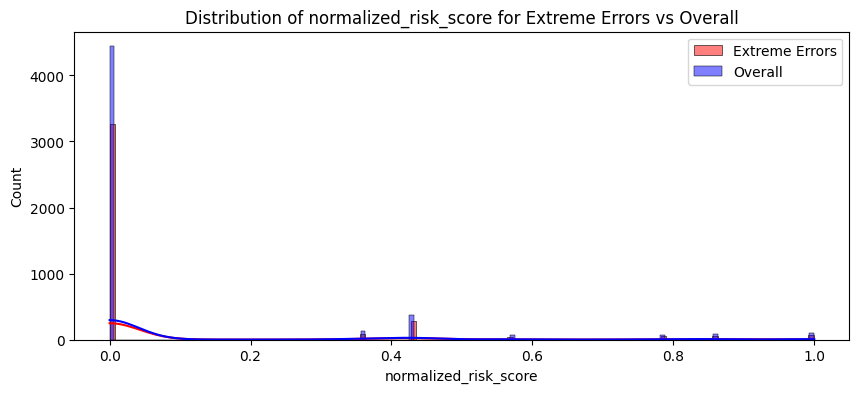

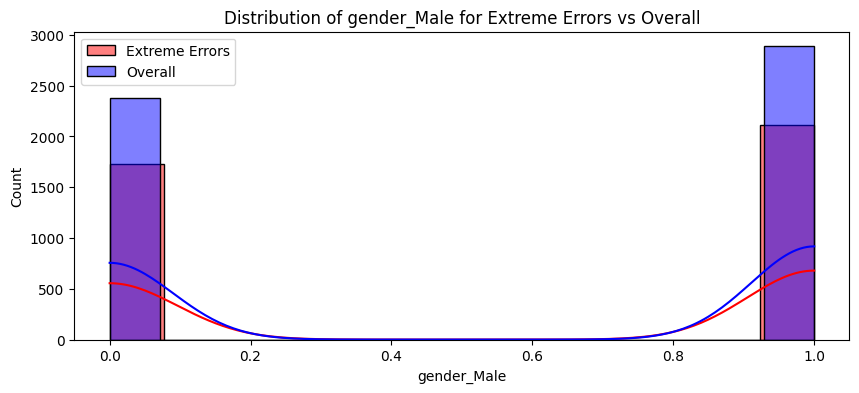

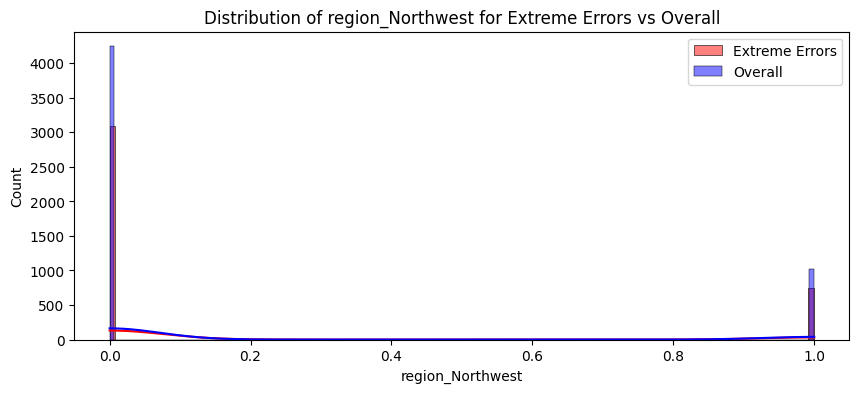

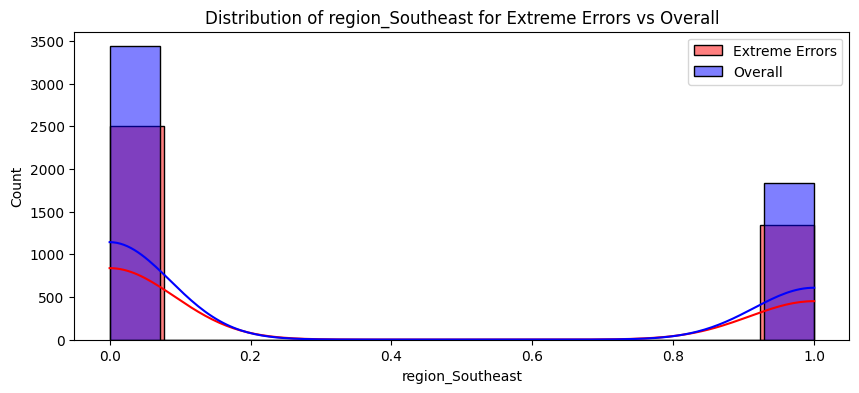

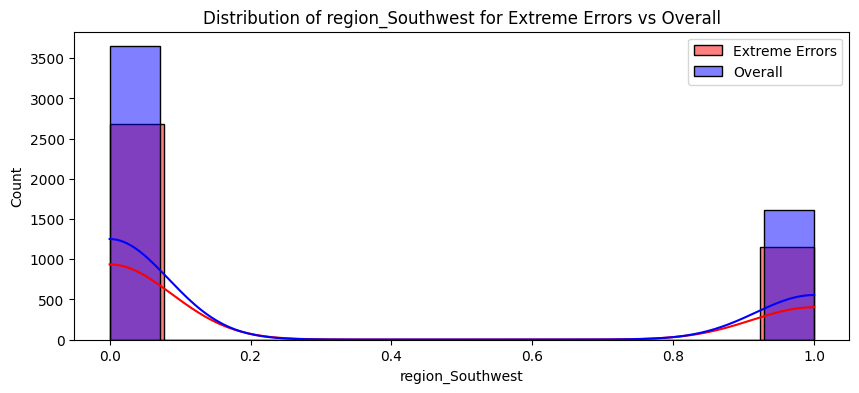

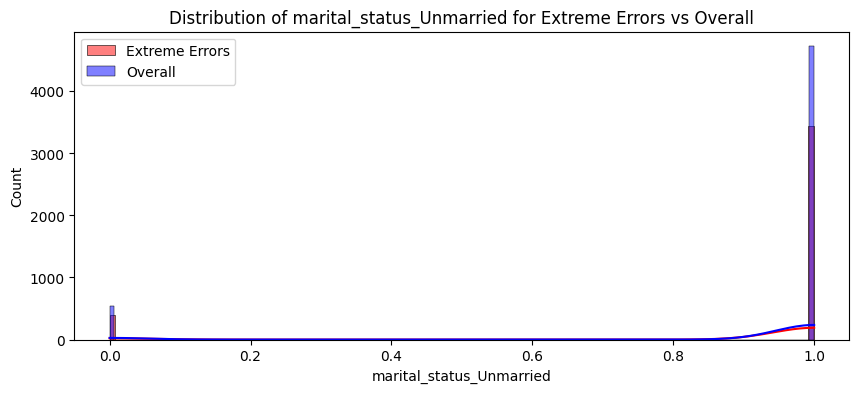

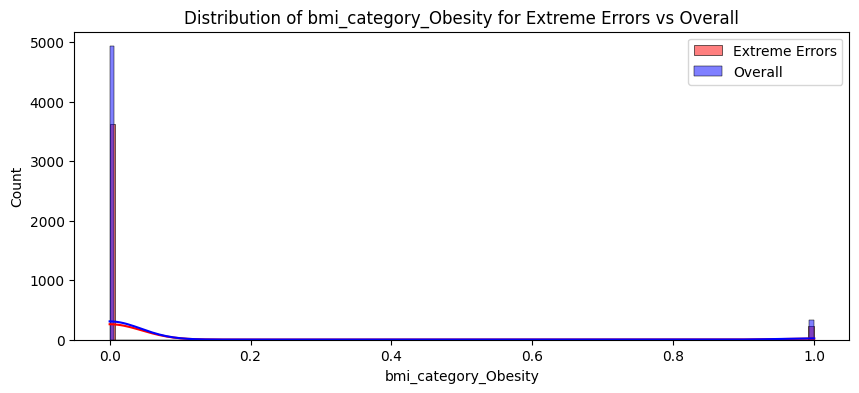

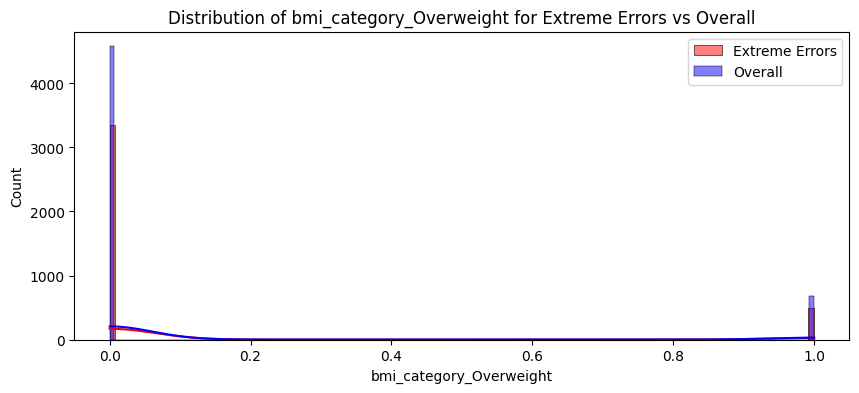

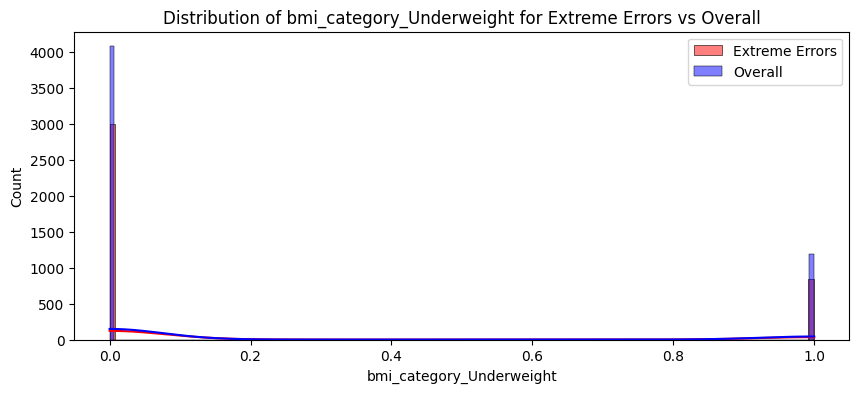

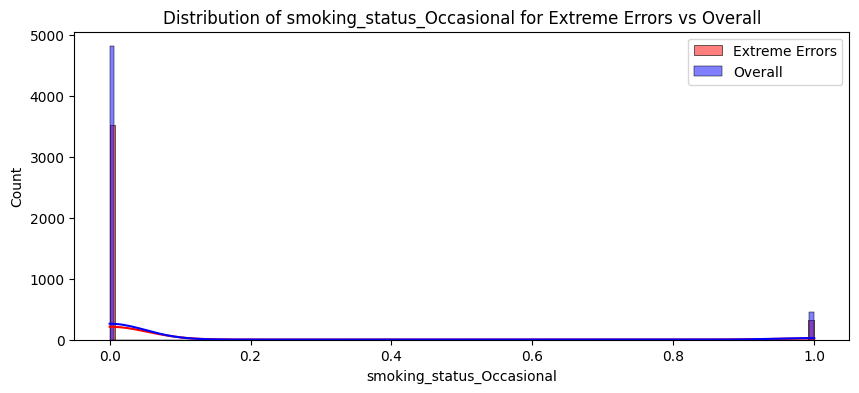

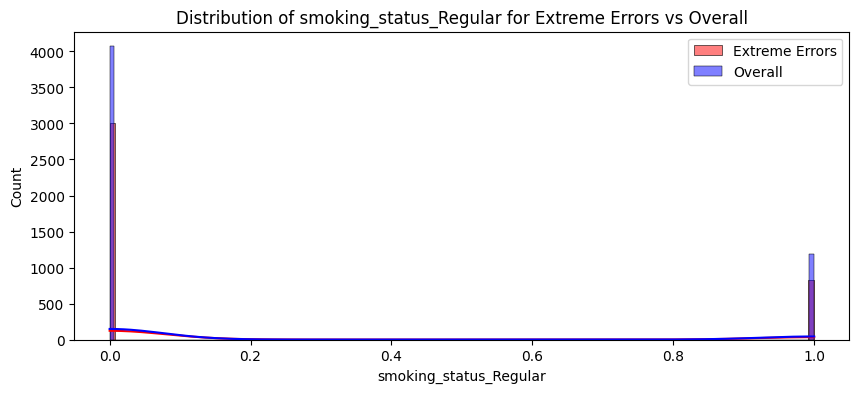

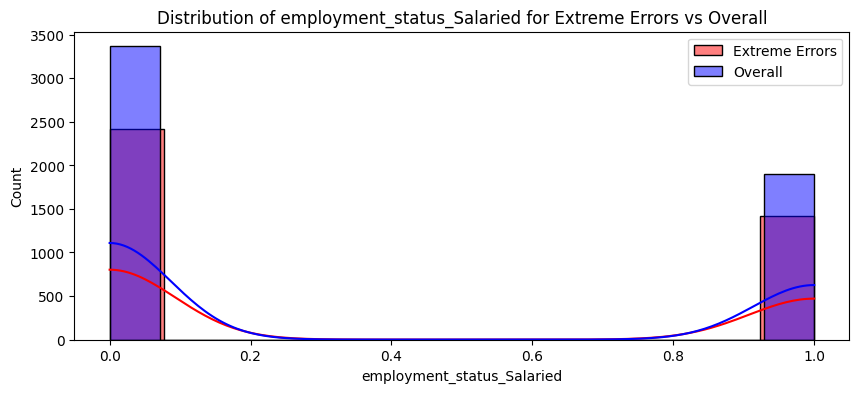

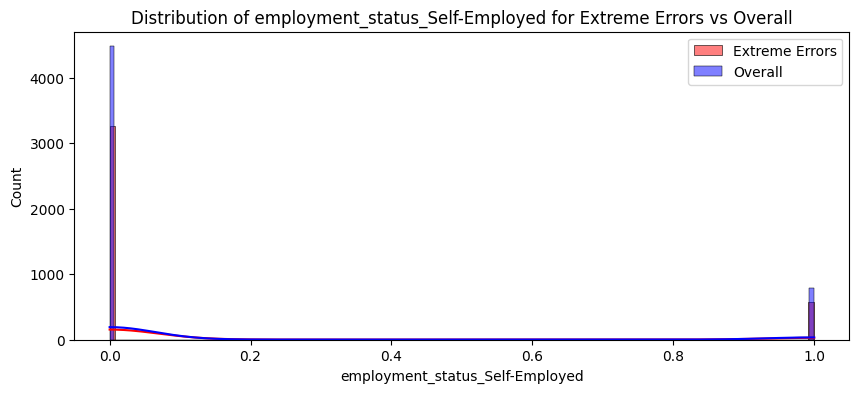

In [101]:
# compare the distribution of features for extreme errors vs overall test set
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

looking at above plots... age column showing some discrepancy 

<Axes: xlabel='age', ylabel='Count'>

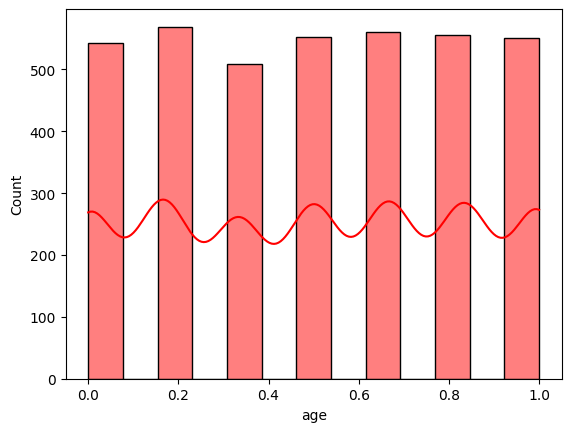

In [102]:
sns.histplot(extreme_errors_df['age'], color='red', label='Extreme Errors', kde=True)

since currently all data points are scaled ...so age is coming from 0 to 1..so we should do inverse transform to get back original data

## REVERSE SCALING

In [103]:
extreme_errors_df['income_level']=-1

In [104]:
# reverse the scaling for the features in extreme_errors_df, it helps to understand the actual values of those features for the customers who are being highly charged
#as we are original data to compare the results

df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,22.0,1.0,-2.0,34.0,1.0
1,22.0,0.0,-2.0,70.0,2.0
2,24.0,0.0,-2.0,35.0,1.0
3,21.0,1.0,-2.0,10.0,1.0
4,19.0,3.0,-2.0,9.0,1.0


In [105]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,3840.000000,3840.000000,3840.0,3840.000000,3840.000000
mean,21.014063,0.716146,-2.0,22.247656,1.317969
std,2.003204,0.941448,0.0,21.620200,0.567589
min,18.000000,0.000000,-2.0,1.000000,1.000000
25%,19.000000,0.000000,-2.0,6.000000,1.000000
50%,21.000000,0.000000,-2.0,16.000000,1.000000
75%,23.000000,1.000000,-2.0,31.000000,2.000000
max,24.000000,3.000000,-2.0,100.000000,3.000000


<Axes: xlabel='age', ylabel='Count'>

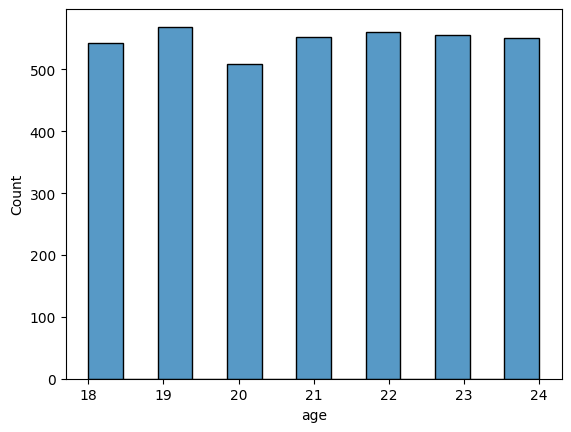

In [106]:
# plot the distribution of age for the customers who are being highly charged .. with original values..reversed values
sns.histplot(df_reversed.age)

so hisplot and describe on df_reversed shows that 75% of population is below age 25

In [107]:
# increase the % people from 75 to 80 or 90
df_reversed['age'].quantile(0.97) # around 97% people are below 25 yrs of age

np.float64(24.0)

# Since Young Model age<25 not performing well to predict insurance plan ...we need to retrain it including additional features